# Imports

In [11]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
import matplotlib.pyplot as plt

import sys
sys.path.append('..')  # to access pipeline.py
from pipeline import (
    AUTOENCODER_FEATURES,
    AUTOENCODER_SCALE_COLS,
    filter_port,
)

# Load and split by protocol

In [12]:
df = pd.read_csv('../ryu-controller/traffic_log.csv')

# keep only normal traffic
df = df[df['Traffic'] == 'Normal']

# split by L4 protocol
df_icmp = df[df['Ip_protocole'] == 'icmp'].copy()
df_tcp  = df[df['Ip_protocole'] == 'tcp'].copy()
df_udp  = df[df['Ip_protocole'] == 'udp'].copy()

print(f'ICMP: {len(df_icmp)} | TCP: {len(df_tcp)} | UDP: {len(df_udp)}')

ICMP: 422 | TCP: 14760 | UDP: 3263


In [13]:
print(df.columns.tolist())

['Timestamp', 'Ip_src', 'Ip_dst', 'Same_ip', 'Port_src', 'Port_dst', 'Ip_protocole', 'Type_protocole', 'Icmp', 'Icmp_code', 'Icmp_type', 'Tcp', 'Udp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Dns', 'Flow_duration', 'Flow_dur_nsec', 'Packet_count', 'Bytes', 'Pkt_per_sec', 'Pkt_per_nsec', 'Bytes_per_sec', 'Bytes_per_nsec', 'Traffic', 'Attack_type']


# Preprocessing function

In [14]:
def preprocess_protocol(df, protocol):
    """Select features, filter ports, scale, return array + fitted scaler."""
    feature_cols = AUTOENCODER_FEATURES[protocol]
    scale_cols   = AUTOENCODER_SCALE_COLS[protocol]

    X = df[feature_cols].copy()

    # port filtering
    if 'Port_dst' in X.columns:
        X['Port_dst'] = X['Port_dst'].apply(filter_port)

    # drop missing
    X = X.dropna()

    # fit scaler on scale columns only
    scaler = StandardScaler()
    X[scale_cols] = scaler.fit_transform(X[scale_cols])

    return X.values.astype(np.float32), scaler

# Autoencoder builder

In [15]:
def build_autoencoder(input_dim):
    """Simple dense autoencoder, bottleneck at 1/4 input size."""
    inp       = Input(shape=(input_dim,))
    encoded   = Dense(input_dim * 2, activation='relu')(inp)
    bottleneck= Dense(input_dim // 4, activation='relu')(encoded)
    decoded   = Dense(input_dim * 2, activation='relu')(bottleneck)
    out       = Dense(input_dim, activation='linear')(decoded)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError())
    return model

# Train one protocol

In [16]:
def train_and_save(df, protocol):
    print(f'\n---{protocol.upper()} ---')

    if len(df) < 30:
        print(f'Not enough samples ({len(df)}), skipping...')
        return None, None

    X, scaler = preprocess_protocol(df, protocol)
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

    model = build_autoencoder(X_train.shape[1])
    model.fit(
        X_train, X_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, X_test),
        verbose=1,
    )

    # compute RMSE on test set to pick threshold
    X_pred = model.predict(X_test)
    mse    = np.mean(np.power(X_test - X_pred, 2), axis=1)
    rmse   = np.sqrt(mse)

    threshold = np.percentile(rmse, 95)
    print(f'Suggested threshold (95th percentile): {threshold:.4f}')

    # plot
    plt.figure()
    plt.hist(rmse, bins=50)
    plt.axvline(threshold, color='red', label=f'threshold={threshold:.4f}')
    plt.title(f'{protocol.upper()} reconstruction error distribution')
    plt.xlabel('RMSE')
    plt.legend()
    plt.show()

    # save model only
    model.save(f'../ryu-controller/{protocol}.h5')
    print(f'Saved {protocol}.h5')

    return threshold, scaler

# Start Traingin


---ICMP ---
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2777 - val_loss: 0.2482
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2579 - val_loss: 0.2301
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2389 - val_loss: 0.2081
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2164 - val_loss: 0.1830
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1902 - val_loss: 0.1566
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1629 - val_loss: 0.1281
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1318 - val_loss: 0.0990
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0995 - val_loss: 0.0704
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0703 - val_loss: 0.0491
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0493 - val_loss: 0.0366
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0356 - val_loss: 0.0289
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0

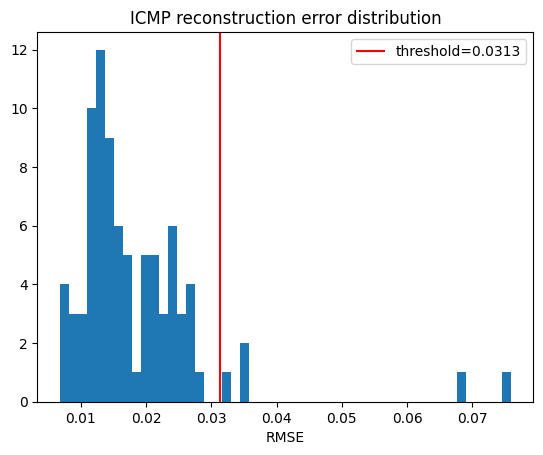

Saved icmp.h5

---TCP ---
Epoch 1/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2275 - val_loss: 0.0796
Epoch 2/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0697 - val_loss: 0.0656
Epoch 3/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0632 - val_loss: 0.0588
Epoch 4/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0524 - val_loss: 0.0467
Epoch 5/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0454 - val_loss: 0.0424
Epoch 6/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0410 - val_loss: 0.0369
Epoch 7/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0353 - val_loss: 0.0317
Epoch 8/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0306 - val_loss: 0.0273
Epoch 9/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0268 - val_loss: 0.0240
Epoch 10/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0238 - val_loss: 0.0215
Epoch 11/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0214 - val_loss: 0.0192
Epoch 12/50
369/369 ━━━━━━

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step
Suggested threshold (95th percentile): 0.1762


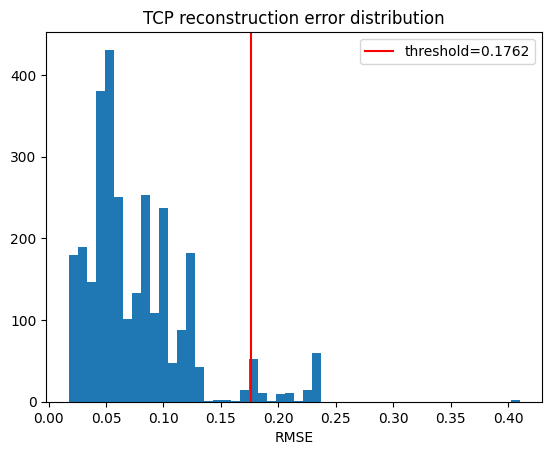

Saved tcp.h5

---UDP ---
Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 99.2163 - val_loss: 50.0542
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.6255 - val_loss: 0.1577
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1821 - val_loss: 0.1535
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1777 - val_loss: 0.1520
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1743 - val_loss: 0.1505
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1680 - val_loss: 0.1392
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1599 - val_loss: 0.1355
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1528 - val_loss: 0.1267
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1418 - val_loss: 0.1151
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1277 - val_loss: 0.0936
Epoch 11/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1021 - val_loss: 0.0756
Epoch 12/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

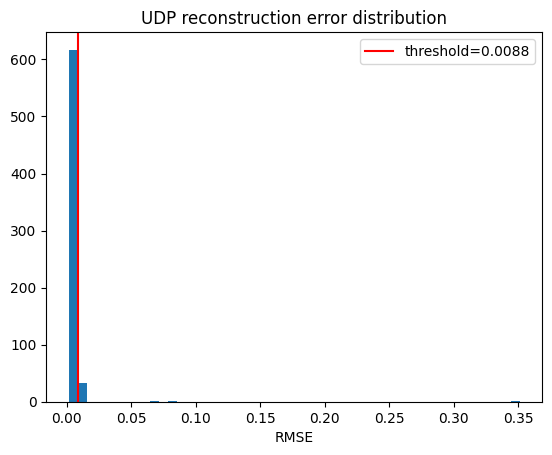

Saved udp.h5


In [18]:
threshold_icmp, scaler_icmp = train_and_save(df_icmp, 'icmp')
threshold_tcp, scaler_tcp = train_and_save(df_tcp, 'tcp')
threshold_udp, scaler_udp = train_and_save(df_udp, 'udp')

# Saving Scalers

### Pickling as standard way of saving. But the the issue is it saves numpy arrays as well, and I am using python 3.8 (venv) for RYU, so this will break the code. i kept only because it is the standard way.

In [19]:
for protocol in ('icmp', 'tcp', 'udp'):
    with open(f'../ryu-controller/std_{protocol}.pkl', 'wb') as f:
        pickle.dump(locals().get(f'scaler_{protocol}'), f)

    print(f'Saved {protocol}.h5 and std_{protocol}.pkl')

Saved icmp.h5 and std_icmp.pkl
Saved tcp.h5 and std_tcp.pkl
Saved udp.h5 and std_udp.pkl


### In order to solve that isee, I saved the scalers manually as json files, so i can skip saving the numpy arrays. I will load these json files in RYU and create the scalers there.

In [20]:
import json

scalers = {
    'icmp': scaler_icmp,
    'tcp':  scaler_tcp,
    'udp':  scaler_udp,
}

for proto, scaler in scalers.items():
    scaler_data = {
        'mean':            scaler.mean_.tolist(),
        'scale':           scaler.scale_.tolist(),
        'var':             scaler.var_.tolist(),
        'n_samples_seen':  int(scaler.n_samples_seen_),
    }
    with open(f'../ryu-controller/std_{proto}.json', 'w') as f:
        json.dump(scaler_data, f)
    print(f'Saved std_{proto}.json')

Saved std_icmp.json
Saved std_tcp.json
Saved std_udp.json


### Here I converted the models to .onnx for compatibility with RYU during runtime. `h5` files are used by keras, which comes with Tensorflow, but since I am using python 3.8 for RYU, there will be compatibility issues with Tensorflow, so I will use ONNX format which is more universal and can be used with different frameworks

In [21]:
import tf2onnx
import onnx
from keras.models import load_model

for proto in ('icmp', 'tcp', 'udp'):
    model = load_model(f'../ryu-controller/{proto}.h5')
    onnx_model, _ = tf2onnx.convert.from_keras(model, opset=13)
    onnx.save(onnx_model, f'../ryu-controller/{proto}.onnx')
    print(f'Saved {proto}.onnx')

Saved icmp.onnx
Saved tcp.onnx
Saved udp.onnx


# Print final thresholds to update in monitor.py

In [22]:
print(f'\nUpdate these in monitor.py:')
print(f'THRESHOLD_ICMP = {threshold_icmp:.4f}')
print(f'THRESHOLD_TCP  = {threshold_tcp:.4f}')
print(f'THRESHOLD_UDP  = {threshold_udp:.4f}')


Update these in monitor.py:
THRESHOLD_ICMP = 0.0313
THRESHOLD_TCP  = 0.1762
THRESHOLD_UDP  = 0.0088
